# EGVP Aftercourt Models & Automation

This notebook measures the automation rate of incoming **EGVP** court attachments.
Every *processed* attachment is scored by the EGVP aftercourt pipeline
(`__ATTACHMENTS_MODELS__["egvp"]` in the `intent_recognition` repo), which runs **7 models**
and writes their outputs to `llm_attachments_predictions`. A single aftercourt type then
"wins" per attachment by priority, and is only flagged `ready_for_automation` once its
required parameters are satisfied.

## Binary models (classical ML — TF-IDF + RandomForest, `AfterCourtClassificationModel`)

| Model | Aftercourt type | Key outputs | Notes |
|---|---|---|---|
| `aftercourt_classification_ladung` | `ladung_va` | `class_pred`, `class_prob`, `slug`, `debtor_name`, `judicial_summon_date` | RF classifier `18-02-2026_binary_ladung_rf_classifier_v1`; params via spaCy `de_core_news_md` NER + regex |
| `aftercourt_classification_pfub` | `pfub_erlass` | `class_pred`, `class_prob`, `slug`, `debtor_name`, `creditor_name` | RF classifier `12-01-2026_binary_pfub_rf_classifier_v1`; low-priority fallback only |

Both share TF-IDF vectorizer `05-12-2026_tf_idf_vectorizer_v1` (S3: `pair-email-classification/models/aftercourt_classification2`).

## LLM models (SGLang-served Qwen)

| Model | Backbone | Key outputs | Purpose |
|---|---|---|---|
| `pfub_erlass_egvp` | QwQ-32B | `is_pfub`, `is_invoice_inside`, `slug`, `debtor_name`, `creditor_name` | Confirm an *issued* Pfändungs- und Überweisungsbeschluss (PfÜB) |
| `drittauskunft_egvp` | Qwen3-4B | `is_dritt`, `is_invoice_inside`, `start_page`, `end_page` | Detect a Drittauskunft / §802l ZPO result payload |
| `vermogenverzeichnis_egvp` | Qwen3-4B | `is_va`, `is_invoice_inside`, `start_page`, `end_page` | Detect an actual Vermögensverzeichnis form |
| `invoice_detection_egvp` | QwQ-32B | `is_invoice_inside`, `start_page`, `end_page` | Locate an invoice / cost section inside a bundle |
| `egvp_standalone_invoice` | QwQ-32B | `invoice`, `reason`, `slug` | Strict single Gerichtsvollzieher payable-invoice classifier |

## Priority order (exactly one type wins per attachment)
1. **ladung_va** — `aftercourt_classification_ladung` (binary)
2. **pfub_erlass** — `pfub_erlass_egvp` (LLM), gated by `is_pfub`
3. **drittauskunft** — `drittauskunft_egvp` (LLM), gated by `is_dritt`
4. **vermogenverzeichnis** — `vermogenverzeichnis_egvp` (LLM), gated by `is_va`
5. **invoice** — `egvp_standalone_invoice` (LLM), gated by `invoice` + `reason == "must_pay"`

## Required params to count as automated (`ready_for_automation`)
- **ladung_va**: `slug`, `debtor_name`, `judicial_summon_date` all present
- **pfub_erlass**: `slug`, `debtor_name` present **and** `is_invoice_inside == False`
- **drittauskunft / vermogenverzeichnis**: `is_invoice_inside == False`
- **invoice**: `invoice == True` **and** `reason == "must_pay"`

> Source of truth: `src/graph/agents/agent_v1/logic/attachments_logic.py`
> (`get_prioritized_aftercourt_prediction`, `is_aftercourt_fully_automated`) and
> `src/shared/constants/aftercourt_required_params.py` (`AFTERCOURT_REQUIRED_PARAMS`).


In [119]:
import os
import json
from ast import literal_eval
from datetime import datetime, timedelta

import pandas as pd

import numpy as np
from IPython.display import clear_output

from python_utilities.db_connection import DbConnection


In [120]:
analytics_db = DbConnection('ANALYTICS', 'PROD_RDS')

INFO [2026-07-03 19:02:08] - PYTHON_UTILITIES - secret_utilities.py - get_db_secret_config - Credentials for database were read from secret.ini file


In [121]:
# start and end is included
# start_date = "2026-05-01"
# end_date = "2026-05-06"
start_date = "2026-06-01"
end_date = "2026-07-01"

In [122]:
all_egvp_messages = analytics_db.sql_to_df(f"""
    SELECT *
    FROM llm_tickets
    WHERE created_at >= '{start_date}'
    AND created_at < '{end_date}'
    AND source_type = 'egvp'
""")

In [123]:
print("Total messages:", len(all_egvp_messages))
print("Unique tickets:", all_egvp_messages['ticket_uuid'].nunique())
# ticket uuid is null
print("Messages with null ticket uuid:", all_egvp_messages['ticket_uuid'].isnull().sum())
print("Date max: {}, date min: {}".format(all_egvp_messages['created_at'].max(), all_egvp_messages['created_at'].min()))

Total messages: 10868
Unique tickets: 10868
Messages with null ticket uuid: 0
Date max: 2026-06-30 22:44:00, date min: 2026-06-01 00:44:00


### get attachments for egvp tickets -> basically the documents

In [124]:
egvp_attachments = analytics_db.sql_to_df(f"""
    SELECT la.*, lt.egvp_id
    FROM llm_attachments la
    LEFT JOIN llm_tickets lt
    ON la.ticket_uuid = lt.ticket_uuid
    WHERE la.created_at >= '{start_date}'
    AND la.created_at < '{end_date}'
""")

In [125]:
egvp_attachments

,id,ticket_uuid,attachment_id,zendesk_id,comment_id,status,file_name,file_extension,status_written_at,created_at,s3_key,s3_bucket,egvp_id
0,3647979,ee15ba86-d9b6-5f80-becc-551e89db7e4b,27836239040028-1,18712281.0,2.783624e+13,rejected_too_short,qr_code_prefilled_payment_details.png,png,2026-06-01 00:12:12,2026-06-01 00:00:07,ocr_source_files/2026-06-01/zendesk_id_1871228...,pair-data-engineering-new,None
1,3647980,480f4553-6b7c-50b7-988e-15499ee46266,27836304013468-1,18712283.0,2.783630e+13,processed,20230726_163253.jpg,jpg,2026-06-01 02:32:56,2026-06-01 00:02:54,ocr_source_files/2026-06-01/zendesk_id_1871228...,pair-data-engineering-new,None
2,3647981,480f4553-6b7c-50b7-988e-15499ee46266,27836304013468-2,18712283.0,2.783630e+13,processed,20230726_163243.jpg,jpg,2026-06-01 02:32:47,2026-06-01 00:02:54,ocr_source_files/2026-06-01/zendesk_id_1871228...,pair-data-engineering-new,None
3,3647982,480f4553-6b7c-50b7-988e-15499ee46266,27836304013468-3,18712283.0,2.783630e+13,processed,20230726_163243.jpg,jpg,2026-06-01 02:33:08,2026-06-01 00:02:54,ocr_source_files/2026-06-01/zendesk_id_1871228...,pair-data-engineering-new,None
4,3647983,480f4553-6b7c-50b7-988e-15499ee46266,27836304013468-4,18712283.0,2.783630e+13,processed,20230726_163243.jpg,jpg,2026-06-01 02:33:07,2026-06-01 00:02:54,ocr_source_files/2026-06-01/zendesk_id_1871228...,pair-data-engineering-new,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...
149456,3797435,5ef07a34-8786-5265-abfe-a5e0f375160c,28573905696412-6,18970570.0,2.857391e+13,processed,IMG_3127.png,png,2026-07-01 00:31:52,2026-06-30 23:32:12,ocr_source_files/2026-06-30/zendesk_id_1897057...,pair-data-engineering-new,None
149457,3797436,5ef07a34-8786-5265-abfe-a5e0f375160c,28573905696412-7,18970570.0,2.857391e+13,processed,IMG_3131.png,png,2026-07-01 00:31:53,2026-06-30 23:32:12,ocr_source_files/2026-06-30/zendesk_id_1897057...,pair-data-engineering-new,None
149458,3797437,c4306f16-9bc9-596d-972c-8f75e7d19274,28574058706972-1,18983766.0,2.857406e+13,processed,RICEVUTA_01-07-2026_125103_268.pdf,pdf,2026-07-01 00:31:54,2026-06-30 23:43:26,ocr_source_files/2026-06-30/zendesk_id_1898376...,pair-data-engineering-new,None
149459,3797438,f03d7404-73a9-5385-ad0e-a0fbcf8d2fa4,28573905478812-1,18983757.0,2.857391e+13,processed,image0.png,png,2026-07-01 00:31:51,2026-06-30 23:32:10,ocr_source_files/2026-06-30/zendesk_id_1898375...,pair-data-engineering-new,None


### only get attachments from egvp

In [67]:
egvp_attachments = egvp_attachments[~egvp_attachments['attachment_id'].str.contains('-')]

In [68]:
egvp_attachments.ticket_uuid.nunique()

10868

###below should be true

In [69]:
egvp_attachments.ticket_uuid.dropna().unique().sort() == all_egvp_messages['ticket_uuid'].dropna().unique().sort()

True

# Automation percentage analysis

### 1) Incoming egvp attachment grouped by date

<Axes: title={'center': 'Daily Incoming EGVP Attachments'}, xlabel='created_at'>

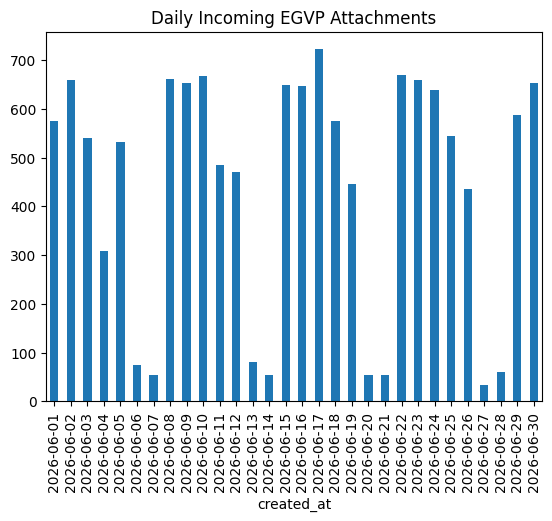

In [70]:
daily_incoming_egvp_attachments = egvp_attachments.groupby(egvp_attachments['created_at'].dt.date).size()
daily_incoming_egvp_attachments.plot(kind='bar', title='Daily Incoming EGVP Attachments')

### 2)Check statuses

In [71]:
import plotly.express as px

daily_status = (
    egvp_attachments
    .groupby([egvp_attachments['created_at'].dt.date, 'status'])
    .size()
    .reset_index(name='count')
    .rename(columns={'created_at': 'day'})
)
daily_status['day'] = daily_status['day'].astype(str)

fig = px.bar(
    daily_status,
    x='day',
    y='count',
    color='status',
    title='Daily Incoming EGVP Attachments by Status',
    labels={'day': 'Day', 'count': 'Count', 'status': 'Status'},
    text='count',
)
fig.update_layout(
    template='plotly_white',
    barmode='stack',
    width=1000,
    height=500,
    legend_title_text='',
)
fig.show()

In [72]:
import plotly.express as px

# group incoming attachments by ISO week (Monday as the week start) and status
week_start = egvp_attachments['created_at'].dt.to_period('W-SUN').dt.start_time.dt.date

weekly_status = (
    egvp_attachments
    .groupby([week_start.rename('week'), 'status'])
    .size()
    .reset_index(name='count')
)
weekly_status['week'] = weekly_status['week'].astype(str)

fig = px.bar(
    weekly_status,
    x='week',
    y='count',
    color='status',
    title='Weekly Incoming EGVP Attachments by Status',
    labels={'week': 'Week (starting)', 'count': 'Count', 'status': 'Status'},
    text='count',
)
fig.update_layout(
    template='plotly_white',
    barmode='stack',
    width=1000,
    height=500,
    legend_title_text='',
)
fig.show()


In [73]:
import plotly.express as px

daily_status = (
egvp_attachments
.groupby([egvp_attachments['created_at'].dt.date, 'status'])
.size()
.reset_index(name='count')
.rename(columns={'created_at': 'day'})
)
daily_status['day'] = daily_status['day'].astype(str)

fig = px.bar(
daily_status,
x='day',
y='count',
color='status',
title='Daily Incoming EGVP Attachments by Status',
labels={'day': 'Day', 'count': 'Count', 'status': 'Status'},
text='count',
)
fig.update_layout(
template='plotly_white',
barmode='stack',
width=1000,
height=500,
legend_title_text='',
)
fig.show()

In [74]:
620+603+610+519+417+31+47

2847

### 3) Get Predictions for EGVP attachments

In [75]:
# get predictions for the corresponding attachments
print("Number of unique attachments:", egvp_attachments['attachment_id'].nunique())

Number of unique attachments: 13241


In [76]:
egvp_attachment_preds = analytics_db.sql_to_df(f"""
    SELECT *
    FROM llm_attachments_predictions
    WHERE attachment_id IN ({', '.join([f"'{att_id}'" for att_id in egvp_attachments.attachment_id.unique()])})
""")

In [77]:
egvp_attachments.attachment_id.nunique()

13241

In [78]:
egvp_attachment_preds.attachment_id.nunique()

12413

In [79]:
print("Among {} unique attachments, {} have predictions.".format(
    egvp_attachments.attachment_id.nunique(),
    egvp_attachment_preds.attachment_id.nunique()
))

Among 13241 unique attachments, 12413 have predictions.


In [80]:
processed_atch_counts = egvp_attachments[egvp_attachments['status'] == 'processed'].shape[0]
print(egvp_attachment_preds.attachment_id.nunique()==processed_atch_counts) # should be true

True


In [81]:
# Reshape long-format predictions -> one row per attachment_id with
# columns like ladung_class_prob, ladung_slug, pfub_debtor_name, etc.

preds = egvp_attachment_preds.copy()

# strip stray single-quotes that wrap the stored values
preds['value'] = preds['value'].astype(str).str.replace("'", "", regex=False)

# build wide column name: "<short_model>_<subtype>"
preds['col'] = (
    preds['model_name'].str.replace('aftercourt_classification_', '', regex=False)
    + '_' + preds['subtype']
)

wide_attch_preds = (
    preds.pivot_table(
        index='attachment_id',
        columns='col',
        values='value',
        aggfunc='first',  # in case of duplicate (attachment_id, col)
    )
    .reset_index()
)
wide_attch_preds.columns.name = None

# cast probability columns to float and fill missing
prob_cols = [c for c in wide_attch_preds.columns if c.endswith('_class_prob')]
for c in prob_cols:
    wide_attch_preds[c] = pd.to_numeric(wide_attch_preds[c], errors='coerce').fillna(-1)

# fill remaining (string) columns with 'none'
str_cols = [c for c in wide_attch_preds.columns if c not in prob_cols + ['attachment_id']]
wide_attch_preds[str_cols] = wide_attch_preds[str_cols].fillna('none')

wide_attch_preds


,attachment_id,drittauskunft_egvp_end_page,drittauskunft_egvp_is_dritt,drittauskunft_egvp_is_invoice_inside,drittauskunft_egvp_kein_ergebnis,drittauskunft_egvp_no_result,drittauskunft_egvp_slug,drittauskunft_egvp_start_page,egvp_standalone_invoice_invoice,egvp_standalone_invoice_reason,...,vermogenverzeichnis_class_pred,vermogenverzeichnis_class_prob,vermogenverzeichnis_egvp_end_page,vermogenverzeichnis_egvp_is_invoice_inside,vermogenverzeichnis_egvp_is_va,vermogenverzeichnis_egvp_slug,vermogenverzeichnis_egvp_start_page,vermogenverzeichnis_end_page,vermogenverzeichnis_is_invoice_inside,vermogenverzeichnis_start_page
0,66964484,none,none,none,none,none,none,none,none,none,...,False,0.020,none,none,none,none,none,-1,False,-1
1,66977396,none,none,none,none,none,none,none,none,none,...,False,0.035,none,none,none,none,none,-1,False,-1
2,66979093,none,none,none,none,none,none,none,none,none,...,False,0.025,none,none,none,none,none,-1,False,-1
3,66979629,none,none,none,none,none,none,none,none,none,...,False,0.020,none,none,none,none,none,1,True,1
4,66979661,none,none,none,none,none,none,none,none,none,...,False,0.030,none,none,none,none,none,2,True,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12408,70460241,1,False,True,none,none,none,1,True,must_pay,...,none,-1.000,1,True,False,none,1,none,none,none
12409,70460244,-1,False,False,none,none,none,-1,False,not_invoice,...,none,-1.000,-1,False,False,none,-1,none,none,none
12410,70460247,-1,False,False,none,none,none,-1,False,not_invoice,...,none,-1.000,-1,False,False,none,-1,none,none,none
12411,70460250,1,True,True,none,False,184518894417,1,False,multiple_docs,...,none,-1.000,1,True,False,none,1,none,none,none


In [82]:
print(wide_attch_preds.attachment_id.nunique())

12413


### 4) Automation Calculation for EGVP attachments using preds

Per-attachment model outputs from `llm_attachments_predictions` are scored against the
**production aftercourt rules** (priority order + required-params gating). Exactly one
aftercourt type wins per attachment — **ladung_va** (binary), **pfub_erlass**,
**drittauskunft**, **vermogenverzeichnis** or **invoice** (LLM models) — mirroring what
the pipeline writes to `egvp_intents.ready_for_automation`. See the models overview at the
top of the notebook.


In [83]:
# ---------------------------------------------------------------------------
# Aftercourt automation rules (predictions-based)
#
# Mirrors the production logic in the intent_recognition repo:
#   * src/graph/agents/agent_v1/logic/attachments_logic.py
#         get_prioritized_aftercourt_prediction()  +  is_aftercourt_fully_automated()
#   * src/shared/constants/aftercourt_required_params.py  (AFTERCOURT_REQUIRED_PARAMS)
#
# Each processed EGVP attachment is scored by 7 models; exactly ONE aftercourt type
# wins, by this priority order:
#   1. ladung_va           -> aftercourt_classification_ladung  (binary TF-IDF + RandomForest)
#   2. pfub_erlass         -> pfub_erlass_egvp                   (LLM, QwQ-32B)
#   3. drittauskunft       -> drittauskunft_egvp                 (LLM, Qwen3-4B)
#   4. vermogenverzeichnis -> vermogenverzeichnis_egvp           (LLM, Qwen3-4B)
#   5. invoice             -> egvp_standalone_invoice            (LLM, QwQ-32B)
# ---------------------------------------------------------------------------

# probability threshold for accepting the ladung binary classifier as automatable
LADUNG_AUTOMATION_PROB_THRESHOLD = 0.95


def _is_true(value):
    """Normalise the stringified booleans stored in llm_attachments_predictions."""
    return value in (True, 'true', 'True', 1, '1')


def _is_present(value):
    """A parameter counts as extracted when it is a non-empty / non-'none' value."""
    return value not in (None, '', 'none', 'None', -1, '-1')


def _to_float(value, default=-1.0):
    try:
        return float(value)
    except (TypeError, ValueError):
        return default


def is_all_params_extracted_ladung(slug, debtor_name, judicial_summon_date):
    return _is_present(slug) and _is_present(debtor_name) and _is_present(judicial_summon_date)


def is_all_params_extracted_pfub(slug, debtor_name):
    return _is_present(slug) and _is_present(debtor_name)


def is_automated_ladung(row):
    # ladung_va: binary classifier confident + slug / debtor_name / summon_date extracted
    is_ladung = _to_float(row.get('ladung_class_prob', -1)) >= LADUNG_AUTOMATION_PROB_THRESHOLD
    return is_ladung and is_all_params_extracted_ladung(
        row.get('ladung_slug'),
        row.get('ladung_debtor_name'),
        row.get('ladung_judicial_summon_date'),
    )


def is_automated_pfub(row):
    # pfub_erlass: LLM says is_pfub, slug + debtor_name extracted, and no invoice inside
    is_pfub = _is_true(row.get('pfub_erlass_egvp_is_pfub'))
    is_invoice_inside = _is_true(row.get('pfub_erlass_egvp_is_invoice_inside'))
    return (
        is_pfub
        and is_all_params_extracted_pfub(
            row.get('pfub_erlass_egvp_slug'),
            row.get('pfub_erlass_egvp_debtor_name'),
        )
        and not is_invoice_inside
    )


def is_automated_dritt(row):
    # drittauskunft: LLM says is_dritt and no invoice inside
    return _is_true(row.get('drittauskunft_egvp_is_dritt')) and not _is_true(
        row.get('drittauskunft_egvp_is_invoice_inside')
    )


def is_automated_va(row):
    # vermogenverzeichnis: LLM says is_va and no invoice inside
    return _is_true(row.get('vermogenverzeichnis_egvp_is_va')) and not _is_true(
        row.get('vermogenverzeichnis_egvp_is_invoice_inside')
    )


def is_automated_invoice(row):
    # standalone invoice: LLM says invoice and reason == 'must_pay'
    return _is_true(row.get('egvp_standalone_invoice_invoice')) and (
        row.get('egvp_standalone_invoice_reason') == 'must_pay'
    )


def get_automated_aftercourt_type(row):
    """Return the single aftercourt type an attachment is automated as (priority order), else 'none'."""
    if is_automated_ladung(row):
        return 'ladung_va'
    if is_automated_pfub(row):
        return 'pfub_erlass'
    if is_automated_dritt(row):
        return 'drittauskunft'
    if is_automated_va(row):
        return 'vermogenverzeichnis'
    if is_automated_invoice(row):
        return 'invoice'
    return 'none'


In [84]:
wide_attch_preds

,attachment_id,drittauskunft_egvp_end_page,drittauskunft_egvp_is_dritt,drittauskunft_egvp_is_invoice_inside,drittauskunft_egvp_kein_ergebnis,drittauskunft_egvp_no_result,drittauskunft_egvp_slug,drittauskunft_egvp_start_page,egvp_standalone_invoice_invoice,egvp_standalone_invoice_reason,...,vermogenverzeichnis_class_pred,vermogenverzeichnis_class_prob,vermogenverzeichnis_egvp_end_page,vermogenverzeichnis_egvp_is_invoice_inside,vermogenverzeichnis_egvp_is_va,vermogenverzeichnis_egvp_slug,vermogenverzeichnis_egvp_start_page,vermogenverzeichnis_end_page,vermogenverzeichnis_is_invoice_inside,vermogenverzeichnis_start_page
0,66964484,none,none,none,none,none,none,none,none,none,...,False,0.020,none,none,none,none,none,-1,False,-1
1,66977396,none,none,none,none,none,none,none,none,none,...,False,0.035,none,none,none,none,none,-1,False,-1
2,66979093,none,none,none,none,none,none,none,none,none,...,False,0.025,none,none,none,none,none,-1,False,-1
3,66979629,none,none,none,none,none,none,none,none,none,...,False,0.020,none,none,none,none,none,1,True,1
4,66979661,none,none,none,none,none,none,none,none,none,...,False,0.030,none,none,none,none,none,2,True,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12408,70460241,1,False,True,none,none,none,1,True,must_pay,...,none,-1.000,1,True,False,none,1,none,none,none
12409,70460244,-1,False,False,none,none,none,-1,False,not_invoice,...,none,-1.000,-1,False,False,none,-1,none,none,none
12410,70460247,-1,False,False,none,none,none,-1,False,not_invoice,...,none,-1.000,-1,False,False,none,-1,none,none,none
12411,70460250,1,True,True,none,False,184518894417,1,False,multiple_docs,...,none,-1.000,1,True,False,none,1,none,none,none


In [85]:
# resolve the single winning aftercourt type per attachment (priority order),
# then derive per-type boolean flags so every attachment is counted at most once
wide_attch_preds['automated_type'] = wide_attch_preds.apply(get_automated_aftercourt_type, axis=1)

wide_attch_preds['is_automated_ladung'] = wide_attch_preds['automated_type'] == 'ladung_va'
wide_attch_preds['is_automated_pfub'] = wide_attch_preds['automated_type'] == 'pfub_erlass'
wide_attch_preds['is_automated_dritt'] = wide_attch_preds['automated_type'] == 'drittauskunft'
wide_attch_preds['is_automated_va'] = wide_attch_preds['automated_type'] == 'vermogenverzeichnis'
wide_attch_preds['is_automated_invoice'] = wide_attch_preds['automated_type'] == 'invoice'


In [86]:
# add dates to wide_attch_preds by merging with egvp_attachments
wide_attch_preds = (wide_attch_preds
    .merge(
        egvp_attachments[['attachment_id', 'created_at']],
        on='attachment_id',
        how='left'
    )
)

In [87]:
daily_incoming_egvp_attachments = egvp_attachments.groupby(egvp_attachments['created_at'].dt.date).size()
daily_automated_ladung = (
    wide_attch_preds[wide_attch_preds['is_automated_ladung']]
    .groupby(wide_attch_preds['created_at'].dt.date)
    .size()
)
daily_automated_pfub = (
    wide_attch_preds[wide_attch_preds['is_automated_pfub']]
    .groupby(wide_attch_preds['created_at'].dt.date)
    .size()
)
daily_automated_dritt = (
    wide_attch_preds[wide_attch_preds['is_automated_dritt']]
    .groupby(wide_attch_preds['created_at'].dt.date)
    .size()
)
daily_automated_va = (
    wide_attch_preds[wide_attch_preds['is_automated_va']]
    .groupby(wide_attch_preds['created_at'].dt.date)
    .size()
)
daily_automated_invoice = (
    wide_attch_preds[wide_attch_preds['is_automated_invoice']]
    .groupby(wide_attch_preds['created_at'].dt.date)
    .size()
)


In [88]:
daily_incoming_egvp_rejected_attachments = (
    egvp_attachments[egvp_attachments['status'] == 'rejected_too_long']
    .groupby(egvp_attachments['created_at'].dt.date)
    .size()
)
daily_incoming_egvp_rejected_attachments

created_at
2026-06-01    31
2026-06-02    42
2026-06-03    27
2026-06-04    40
2026-06-05    35
2026-06-06     6
2026-06-07     4
2026-06-08    48
2026-06-09    39
2026-06-10    45
2026-06-11    31
2026-06-12    39
2026-06-13     9
2026-06-14     3
2026-06-15    34
2026-06-16    37
2026-06-17    31
2026-06-18    35
2026-06-19    26
2026-06-20     8
2026-06-21     4
2026-06-22    49
2026-06-23    56
2026-06-24    28
2026-06-25    26
2026-06-26    18
2026-06-27     3
2026-06-28    14
2026-06-29    31
2026-06-30    27
dtype: int64

In [89]:
# Daily automation rate (%) per aftercourt type vs total incoming attachments
daily_df = (
    pd.concat(
        [
            daily_incoming_egvp_attachments.rename('total'),
            daily_incoming_egvp_rejected_attachments.rename('rejected'),
            daily_automated_ladung.rename('ladung'),
            daily_automated_pfub.rename('pfub'),
            daily_automated_dritt.rename('dritt'),
            daily_automated_va.rename('va'),
            daily_automated_invoice.rename('invoice'),
        ],
        axis=1,
    )
    .fillna(0)
    .sort_index()
)
daily_df.index = pd.to_datetime(daily_df.index)
daily_df.index.name = 'day'
for _c in ['ladung', 'pfub', 'dritt', 'va', 'invoice', 'rejected']:
    daily_df[f'{_c}_pct'] = (daily_df[_c] / daily_df['total'] * 100).round(2)

plot_df = daily_df.reset_index()

y_cols = ['ladung_pct', 'pfub_pct', 'dritt_pct', 'va_pct', 'invoice_pct', 'rejected_pct']
abs_cols = {
    'ladung_pct': 'ladung',
    'pfub_pct': 'pfub',
    'dritt_pct': 'dritt',
    'va_pct': 'va',
    'invoice_pct': 'invoice',
    'rejected_pct': 'rejected',
}
labels_map = {
    'ladung_pct': 'LADUNG (binary)',
    'pfub_pct': 'PFUB (LLM)',
    'dritt_pct': 'DRITT (LLM)',
    'va_pct': 'VA (LLM)',
    'invoice_pct': 'INVOICE (LLM)',
    'rejected_pct': 'REJECTED (too long)',
}

fig = px.line(
    plot_df,
    x='day',
    y=y_cols,
    markers=True,
    title='Daily Automation Rate by Aftercourt Type (predictions) — Ladung / PFUB / Dritt / VA / Invoice',
    labels={'day': 'Day', 'value': 'Rate (%)', 'variable': 'Series'},
    color_discrete_map={
        'ladung_pct': '#1f77b4',
        'pfub_pct': '#ff7f0e',
        'dritt_pct': '#9467bd',
        'va_pct': '#2ca02c',
        'invoice_pct': '#8c564b',
        'rejected_pct': '#d62728',
    },
)

# add absolute counts as hover info; dash the rejected line to distinguish it
for trace in fig.data:
    col = trace.name
    abs_col = abs_cols[col]
    trace.customdata = np.stack(
        [daily_df[abs_col].values, daily_df['total'].values], axis=-1
    )
    trace.hovertemplate = (
        '<b>%{x|%Y-%m-%d}</b><br>'
        'Total incoming: %{customdata[1]:.0f}<br>'
        'Count: %{customdata[0]:.0f} / %{customdata[1]:.0f}<br>'
        'Rate: %{y:.2f}%<extra>' + labels_map[col] + '</extra>'
    )
    if col == 'rejected_pct':
        trace.line.dash = 'dash'

# rename legend entries
fig.for_each_trace(lambda t: t.update(name=labels_map[t.name]))

fig.update_layout(
    template='plotly_white',
    width=1000,
    height=500,
    hovermode='x unified',
    yaxis=dict(ticksuffix='%', range=[0, 100]),
    legend_title_text='',
)
fig.update_traces(line=dict(width=3), marker=dict(size=9), selector=dict(mode='lines+markers'))
fig.show()


In [90]:
total_mean = daily_df['total'].mean()
ladung_auto_mean = daily_df['ladung'].mean()
pfub_auto_mean = daily_df['pfub'].mean()
dritt_auto_mean = daily_df['dritt'].mean()
va_auto_mean = daily_df['va'].mean()
invoice_auto_mean = daily_df['invoice'].mean()
overall_auto_mean = ladung_auto_mean + pfub_auto_mean + dritt_auto_mean + va_auto_mean + invoice_auto_mean


def _pct(part, whole):
    return (part / whole * 100) if whole > 0 else 0


print("Average daily incoming attachments: {:.2f}".format(total_mean))
print("Average daily automated Ladung: {:.2f} ({:.2f}%)".format(ladung_auto_mean, _pct(ladung_auto_mean, total_mean)))
print("Average daily automated PFUB: {:.2f} ({:.2f}%)".format(pfub_auto_mean, _pct(pfub_auto_mean, total_mean)))
print("Average daily automated Dritt: {:.2f} ({:.2f}%)".format(dritt_auto_mean, _pct(dritt_auto_mean, total_mean)))
print("Average daily automated VA: {:.2f} ({:.2f}%)".format(va_auto_mean, _pct(va_auto_mean, total_mean)))
print("Average daily automated Invoice: {:.2f} ({:.2f}%)".format(invoice_auto_mean, _pct(invoice_auto_mean, total_mean)))
print("Overall average daily automation rate: {:.2f}%".format(_pct(overall_auto_mean, total_mean)))


Average daily incoming attachments: 441.37
Average daily automated Ladung: 56.63 (12.83%)
Average daily automated PFUB: 58.20 (13.19%)
Average daily automated Dritt: 40.07 (9.08%)
Average daily automated VA: 6.27 (1.42%)
Average daily automated Invoice: 57.53 (13.04%)
Overall average daily automation rate: 49.55%


In [91]:
total_incoming = daily_df['total'].sum()
ladung_auto_total = daily_df['ladung'].sum()
pfub_auto_total = daily_df['pfub'].sum()
dritt_auto_total = daily_df['dritt'].sum()
va_auto_total = daily_df['va'].sum()
invoice_auto_total = daily_df['invoice'].sum()
overall_auto_total = ladung_auto_total + pfub_auto_total + dritt_auto_total + va_auto_total + invoice_auto_total


def _pct_total(part):
    return (part / total_incoming * 100) if total_incoming > 0 else 0


print("Total incoming attachments: {:.0f}".format(total_incoming))
print("Total automated Ladung: {:.0f} ({:.2f}%)".format(ladung_auto_total, _pct_total(ladung_auto_total)))
print("Total automated PFUB: {:.0f} ({:.2f}%)".format(pfub_auto_total, _pct_total(pfub_auto_total)))
print("Total automated Dritt: {:.0f} ({:.2f}%)".format(dritt_auto_total, _pct_total(dritt_auto_total)))
print("Total automated VA: {:.0f} ({:.2f}%)".format(va_auto_total, _pct_total(va_auto_total)))
print("Total automated Invoice: {:.0f} ({:.2f}%)".format(invoice_auto_total, _pct_total(invoice_auto_total)))
print("Overall total automation rate: {:.2f}%".format(_pct_total(overall_auto_total)))


Total incoming attachments: 13241
Total automated Ladung: 1699 (12.83%)
Total automated PFUB: 1746 (13.19%)
Total automated Dritt: 1202 (9.08%)
Total automated VA: 188 (1.42%)
Total automated Invoice: 1726 (13.04%)
Overall total automation rate: 49.55%


### 5) Automation Calculation using egvp intents table

In [126]:
egvp_intents = analytics_db.sql_to_df(f"""
    SELECT *
    FROM egvp_intents
    WHERE created_at >= '{start_date}'
    AND created_at <= '{end_date}'
    AND intents LIKE '%%"channel": "egvp"%%'
    AND attachment_id IN ({', '.join([f"'{att_id}'" for att_id in egvp_attachments.attachment_id.unique()])})
""")


In [127]:
total_found_intents = len(egvp_intents)
total_attachments_given_dates = egvp_attachments['attachment_id'].nunique()
total_processed_attachments = egvp_attachments[egvp_attachments['status'] == 'processed']['attachment_id'].nunique()
total_rejected_attachments = egvp_attachments[egvp_attachments['status'] == 'rejected_too_long']['attachment_id'].nunique()
print("Total found intents: {}, total attachments given dates: {}, total processed attachments: {}, total rejected attachments: {}".format(
    total_found_intents,
    total_attachments_given_dates,
    total_processed_attachments,
    total_rejected_attachments
))

Total found intents: 13240, total attachments given dates: 149461, total processed attachments: 107405, total rejected attachments: 5303


In [128]:
egvp_intents['attachment_id'] = egvp_intents['attachment_id'].astype(str)

In [129]:
intent_cant_found_attachment_ids = set(egvp_attachments['attachment_id'].unique()) - set(egvp_intents['attachment_id'].unique())

In [1]:
egvp_intents

NameError: name 'egvp_intents' is not defined

In [130]:
print("Total intents:", len(egvp_intents))
print("Unique attachments in intents:", egvp_intents['attachment_id'].nunique())
print("Intents can't found for {} attachments.".format(len(intent_cant_found_attachment_ids)))

Total intents: 13240
Unique attachments in intents: 13240
Intents can't found for 136221 attachments.


In [132]:
automation_from_intents_db = egvp_attachments.merge(
    egvp_intents[['attachment_id', 'intents','ready_for_automation']],
    on='attachment_id',
    how='left'
)

In [133]:
def find_how_automated(row):
    intent = row['intents']
    if intent:
        try:
            intent = intent.lower()
        except:
            return "none"
        if "ladung_va" in intent:
            return "ladung_va"
        elif "pfub_erlass" in intent:
            return "pfub_erlass"
        elif "vermogen" in intent:
            return "va"
        elif "dritt" in intent:
            return "dritt"
        elif '"aftercourt_type": "invoice"' in intent:
            return "invoice"
        else:
            return "none"
    else:
        return "none"
        

automation_from_intents_db['how_automated'] = automation_from_intents_db.apply(lambda row: find_how_automated(row) if row['ready_for_automation'] else 'none', axis=1)

In [99]:
automation_from_intents_db['how_automated'].value_counts()

how_automated
none           7318
invoice        1681
pfub_erlass    1666
ladung_va      1637
dritt           766
va              173
Name: count, dtype: int64

In [134]:
automation_from_intents_db['how_automated'].value_counts()

how_automated
none           143538
invoice          1681
pfub_erlass      1666
ladung_va        1637
dritt             766
va                173
Name: count, dtype: int64

In [100]:
check = automation_from_intents_db[automation_from_intents_db['how_automated']=="va"]
check

,id,ticket_uuid,attachment_id,zendesk_id,comment_id,status,file_name,file_extension,status_written_at,created_at,s3_key,s3_bucket,egvp_id,intents,ready_for_automation,how_automated
2840,3682907,5c024c12-1b20-510b-aa48-16959cb182bf,67887078,NaN,NaN,processed,67887078_VV_275263.pdf,pdf,2026-06-08 13:30:02,2026-06-08 08:44:00,ocr_source_files/2026-06-08/egvp_id_383382/678...,pair-data-engineering-new,NRW_B217809021804134e9be5fa-14c1-4b02-a36c-3d8...,"[{""params"": {""end_page"": null, ""start_page"": n...",1.0,va
2937,3684201,b964d443-b15a-5b60-a365-54d5b59513bd,67893670,NaN,NaN,processed,67893670_VV_74426_9882.pdf,pdf,2026-06-08 15:28:13,2026-06-08 10:44:00,ocr_source_files/2026-06-08/egvp_id_383472/678...,pair-data-engineering-new,NRW_B21780910547093d9b29cca-66a5-4b80-9ae6-a10...,"[{""params"": {""end_page"": null, ""start_page"": n...",1.0,va
2959,3684223,1612f89a-4cf6-57f0-a02d-7be60c1bb912,67893754,NaN,NaN,processed,67893754_vermoegensverzeichnis-signed.pdf,pdf,2026-06-08 15:28:13,2026-06-08 10:44:00,ocr_source_files/2026-06-08/egvp_id_383492/678...,pair-data-engineering-new,NRW_B2178091053752337f39690-f54a-4a3c-a104-68b...,"[{""params"": {""end_page"": null, ""start_page"": n...",1.0,va
3037,3684892,3fbca898-a027-5e05-a3e3-3115061d06c3,67895793,NaN,NaN,processed,67895793_VV_69126_5947.pdf,pdf,2026-06-08 16:26:02,2026-06-08 11:44:00,ocr_source_files/2026-06-08/egvp_id_383574/678...,pair-data-engineering-new,NRW_B217809134660566f6f35ae-4f00-4636-98e8-ecb...,"[{""params"": {""end_page"": null, ""start_page"": n...",1.0,va
3044,3684899,7ca38298-5d4e-5690-8980-2b20c65198b1,67895819,NaN,NaN,processed,67895819_Vermoegensverzeichnis_zu_DRII-056225.pdf,pdf,2026-06-08 16:26:02,2026-06-08 11:44:00,ocr_source_files/2026-06-08/egvp_id_383579/678...,pair-data-engineering-new,NRW_B217809151829979ab49b2a-a463-4b3c-865a-b94...,"[{""params"": {""end_page"": null, ""start_page"": n...",1.0,va
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13071,3795195,cd0954d8-e645-5543-97a3-20ea52b9f4d4,70452763,NaN,NaN,processed,70452763_VV_45626_2871.pdf,pdf,2026-06-30 18:22:14,2026-06-30 13:44:00,ocr_source_files/2026-06-30/egvp_id_400431/704...,pair-data-engineering-new,NRW_B21782823098829423e189e-cbd1-46de-8d62-280...,"[{""params"": {""end_page"": null, ""start_page"": n...",1.0,va
13078,3795774,a0c03bdc-3e20-57f5-a5b9-4414c10e8e17,70454459,NaN,NaN,processed,70454459_GerhardVAK.pdf,pdf,2026-06-30 18:20:32,2026-06-30 14:44:00,ocr_source_files/2026-06-30/egvp_id_400642/704...,pair-data-engineering-new,NRW_B21782824966625bf9d90de-1be4-4d2a-9e87-b19...,"[{""params"": {""end_page"": null, ""start_page"": n...",1.0,va
13165,3796095,9fd774ff-fabf-545e-84c9-a7ce2a6bfb34,70455606,NaN,NaN,processed,70455606_VAK_Jozic.pdf,pdf,2026-06-30 18:23:52,2026-06-30 15:44:00,ocr_source_files/2026-06-30/egvp_id_400716/704...,pair-data-engineering-new,NRW_B21782831169201df706a79-bfc5-4a89-9ff0-7d4...,"[{""params"": {""end_page"": null, ""start_page"": n...",1.0,va
13176,3796106,cfc10a2b-f2e0-59d9-b6f0-55741379b89c,70455645,NaN,NaN,processed,70455645_Noelker_VV_.pdf,pdf,2026-06-30 18:24:01,2026-06-30 15:44:00,ocr_source_files/2026-06-30/egvp_id_400725/704...,pair-data-engineering-new,NRW_B21782830835134a740706b-90af-4277-9957-8be...,"[{""params"": {""end_page"": null, ""start_page"": n...",1.0,va


In [101]:
check.egvp_id.unique()

array(['NRW_B217809021804134e9be5fa-14c1-4b02-a36c-3d883818a9ab',
       'NRW_B21780910547093d9b29cca-66a5-4b80-9ae6-a1055e703060',
       'NRW_B2178091053752337f39690-f54a-4a3c-a104-68b1b936c156',
       'NRW_B217809134660566f6f35ae-4f00-4636-98e8-ecb955cf89eb',
       'NRW_B217809151829979ab49b2a-a463-4b3c-865a-b948eb52c448',
       'NRW_B217809216735822d7b16e5-7c2c-4d88-86e2-211598254695',
       'NRW_B217809241375039bb5387f-f030-4838-b128-9dacb6873192',
       'NRW_B217809261158641da6184d-0b26-43c3-9769-9c44bc0419f1',
       'NRW_B217809961748796a8afec2-85f3-4b25-a32f-3e9862a88259',
       'NRW_B217810093335105684caa6-312c-4361-93db-1de5d0445d82',
       'NRW_B217810072454694acfd84a-99fd-40cd-8513-43b0b3b2bdc5',
       'NRW_B21781007725424e0e0cfa5-adda-41f6-96cc-499baa3a070d',
       'NRW_B21781085068430485ea856-7f7b-4fb3-a777-244844d7ae7d',
       'NRW_B21781090954878eb952aba-172a-4e56-9a01-c90a1068ee71',
       'NRW_B2178109432035220e71ceb-12e0-46cf-aefc-46e87384a74e',
       'NR

In [102]:
automation_from_intents_db

,id,ticket_uuid,attachment_id,zendesk_id,comment_id,status,file_name,file_extension,status_written_at,created_at,s3_key,s3_bucket,egvp_id,intents,ready_for_automation,how_automated
0,3648022,ad04fb65-f04a-5557-accf-bc8de58c1f63,66964484,NaN,NaN,processed,66964484_DR_II_700_26_aus_Schreibmaschine.PDF,pdf,2026-06-01 02:07:18,2026-06-01 00:44:00,ocr_source_files/2026-06-01/egvp_id_379438/669...,pair-data-engineering-new,NRW_B2178027206323956923770-e2a0-48e0-8c7d-d39...,"[{""params"": {""slug"": ""143112083983"", ""debtor_n...",1.0,ladung_va
1,3648087,47d2716d-6c50-5624-b623-b07152806aaf,66977396,NaN,NaN,processed,66977396_Dokument_88226_31052026_163604.pdf,pdf,2026-06-01 05:50:22,2026-06-01 04:44:00,ocr_source_files/2026-06-01/egvp_id_379439/669...,pair-data-engineering-new,NRW_B21780283786682100b440f-778d-4ad3-b512-0e1...,"[{""params"": {}, ""channel"": ""egvp"", ""attachment...",0.0,none
2,3648189,416daf34-5232-5a41-83f1-85fd43020475,66979093,NaN,NaN,processed,66979093_Dokument_88226_01062026_053214.pdf,pdf,2026-06-01 06:28:53,2026-06-01 05:44:00,ocr_source_files/2026-06-01/egvp_id_379440/669...,pair-data-engineering-new,NRW_B2178028965795706d896b6-36b7-4063-b9b5-2ae...,"[{""params"": {}, ""channel"": ""egvp"", ""attachment...",0.0,none
3,3648190,818e250a-7909-50ea-83dc-fc5c761ccf7b,66979629,NaN,NaN,processed,66979629_DR-II_069226_Nachr_Textbaustein_pzur_...,pdf,2026-06-01 06:28:54,2026-06-01 05:44:00,ocr_source_files/2026-06-01/egvp_id_379441/669...,pair-data-engineering-new,NRW_B217802884687215267e12f-16e9-4aba-8298-38d...,"[{""params"": {}, ""channel"": ""egvp"", ""attachment...",0.0,none
4,3648191,818e250a-7909-50ea-83dc-fc5c761ccf7b,66979630,NaN,NaN,rejected_too_long,66979630_PFUeB1.pdf,pdf,2026-06-01 06:12:35,2026-06-01 05:44:00,ocr_source_files/2026-06-01/egvp_id_379441/669...,pair-data-engineering-new,NRW_B217802884687215267e12f-16e9-4aba-8298-38d...,"[{""params"": {}, ""channel"": ""egvp"", ""attachment...",0.0,none
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13236,3797357,ff4b7bed-d325-50ef-a5dd-83e8012b2924,70460244,NaN,NaN,processed,70460244_Dokument_59326_30062026_214250.pdf,pdf,2026-06-30 22:34:33,2026-06-30 21:44:00,ocr_source_files/2026-06-30/egvp_id_400806/704...,pair-data-engineering-new,NRW_B2178284984357849555590-f86b-41c8-984b-4be...,"[{""params"": {""slug"": ""184266800251"", ""debtor_n...",1.0,ladung_va
13237,3797358,2bc89617-06e2-5b5c-9d20-cc6dee014c04,70460247,NaN,NaN,processed,70460247_Dokument_136524_30062026_190229.pdf,pdf,2026-06-30 22:34:35,2026-06-30 21:44:00,ocr_source_files/2026-06-30/egvp_id_400807/704...,pair-data-engineering-new,NRW_B2178285189623288ffccde-5ac2-40f7-b1ad-e52...,"[{""params"": {}, ""channel"": ""egvp"", ""attachment...",0.0,none
13238,3797359,5ebecf6c-93ce-5719-ba82-3a464cfd22f9,70460250,NaN,NaN,processed,70460250_Dokumente_78326_30062026_222700.pdf,pdf,2026-06-30 22:34:29,2026-06-30 21:44:00,ocr_source_files/2026-06-30/egvp_id_400808/704...,pair-data-engineering-new,NRW_B217828517383486da9cae3-619e-4438-8516-42b...,"[{""params"": {""slug"": ""184518894417"", ""end_page...",0.0,none
13239,3797360,e531e137-0fb5-5c06-8fa1-c5c49876e441,70460253,NaN,NaN,rejected_too_long,70460253_DR_II_465_26_VAK__Sch_hat_VAK_bereits...,pdf,2026-06-30 22:12:31,2026-06-30 21:44:00,ocr_source_files/2026-06-30/egvp_id_400809/704...,pair-data-engineering-new,NRW_B21782851163050c04476a6-5102-4abb-a0b7-465...,"[{""params"": {}, ""channel"": ""egvp"", ""attachment...",0.0,none


In [135]:
daily_incoming_egvp_attachments = automation_from_intents_db.groupby(automation_from_intents_db['created_at'].dt.date).size()
daily_automated_ladung_from_egvp_intets = automation_from_intents_db[automation_from_intents_db['how_automated'] == 'ladung_va'].groupby(automation_from_intents_db['created_at'].dt.date).size()
daily_automated_pfub_from_egvp_intets = automation_from_intents_db[automation_from_intents_db['how_automated'] == 'pfub_erlass'].groupby(automation_from_intents_db['created_at'].dt.date).size()
daily_automated_va_from_egvp_intets = automation_from_intents_db[automation_from_intents_db['how_automated'] == 'va'].groupby(automation_from_intents_db['created_at'].dt.date).size()
daily_automated_dritt_from_egvp_intets = automation_from_intents_db[automation_from_intents_db['how_automated'] == 'dritt'].groupby(automation_from_intents_db['created_at'].dt.date).size()
daily_automated_invoice_from_egvp_intets = automation_from_intents_db[automation_from_intents_db['how_automated'] == 'invoice'].groupby(automation_from_intents_db['created_at'].dt.date).size()

### plot graph

In [136]:
# Daily automation rate (%) for ladung, pfub, va, dritt and invoice from egvp_intents table
daily_intents_df = (
    pd.concat(
        [
            daily_incoming_egvp_attachments.rename('total'),
            daily_automated_ladung_from_egvp_intets.rename('ladung'),
            daily_automated_pfub_from_egvp_intets.rename('pfub'),
            daily_automated_va_from_egvp_intets.rename('va'),
            daily_automated_dritt_from_egvp_intets.rename('dritt'),
            daily_automated_invoice_from_egvp_intets.rename('invoice'),
        ],
        axis=1,
    )
    .fillna(0)
    .sort_index()
)
daily_intents_df.index = pd.to_datetime(daily_intents_df.index)
daily_intents_df.index.name = 'day'
daily_intents_df['ladung_pct'] = (daily_intents_df['ladung'] / daily_intents_df['total'] * 100).round(2)
daily_intents_df['pfub_pct'] = (daily_intents_df['pfub'] / daily_intents_df['total'] * 100).round(2)
daily_intents_df['va_pct'] = (daily_intents_df['va'] / daily_intents_df['total'] * 100).round(2)
daily_intents_df['dritt_pct'] = (daily_intents_df['dritt'] / daily_intents_df['total'] * 100).round(2)
daily_intents_df['invoice_pct'] = (daily_intents_df['invoice'] / daily_intents_df['total'] * 100).round(2)

plot_df = daily_intents_df.reset_index()

y_cols = ['ladung_pct', 'pfub_pct', 'va_pct', 'dritt_pct', 'invoice_pct']
abs_cols = {'ladung_pct': 'ladung', 'pfub_pct': 'pfub', 'va_pct': 'va', 'dritt_pct': 'dritt', 'invoice_pct': 'invoice'}
labels_map = {
    'ladung_pct': 'LADUNG (ladung_va)',
    'pfub_pct': 'PFUB (pfub_erlass)',
    'va_pct': 'VA (vermogen)',
    'dritt_pct': 'DRITT (dritt)',
    'invoice_pct': 'INVOICE (invoice)',
}

fig = px.line(
    plot_df,
    x='day',
    y=y_cols,
    markers=True,
    title='Daily Automation Rate from EGVP Intents — Ladung vs PFUB vs VA vs Dritt vs Invoice',
    labels={'day': 'Day', 'value': 'Rate (%)', 'variable': 'Series'},
    color_discrete_map={
        'ladung_pct': '#1f77b4',
        'pfub_pct': '#ff7f0e',
        'va_pct': '#2ca02c',
        'dritt_pct': '#9467bd',
        'invoice_pct': '#d62728',
    },
)

for trace in fig.data:
    col = trace.name
    abs_col = abs_cols[col]
    trace.customdata = np.stack(
        [daily_intents_df[abs_col].values, daily_intents_df['total'].values], axis=-1
    )
    trace.hovertemplate = (
        '<b>%{x|%Y-%m-%d}</b><br>'
        'Total incoming: %{customdata[1]:.0f}<br>'
        'Automated: %{customdata[0]:.0f} / %{customdata[1]:.0f}<br>'
        'Rate: %{y:.2f}%<extra>' + labels_map[col] + '</extra>'
    )

fig.for_each_trace(lambda t: t.update(name=labels_map[t.name]))

fig.update_layout(
    template='plotly_white',
    width=1000,
    height=500,
    hovermode='x unified',
    yaxis=dict(ticksuffix='%', range=[0, 100]),
    legend_title_text='',
)
fig.update_traces(line=dict(width=3), marker=dict(size=9))
fig.show()

# Combine automation calculation using preds and egvp intents

Cross-check the two independent automation measurements for **every aftercourt type**
(ladung, pfub, dritt, va, invoice):

- **preds** — recomputed locally from `llm_attachments_predictions` using the production
  rules (section 4).
- **intents** — read straight from `egvp_intents.ready_for_automation` (section 5).

In the chart each aftercourt type keeps one colour; **solid = preds**, **dashed = intents**.
Large gaps between the solid and dashed line of the same colour flag a mismatch between the
locally reproduced rules and what the pipeline actually persisted.


In [105]:
# Combined: daily automation rate (%) from predictions vs egvp_intents table,
# for every aftercourt type. Same hue per type, solid = predictions, dashed = egvp_intents.
# NOTE: `daily_incoming_egvp_attachments` was overwritten in section 5 with the
# intents-merged frame (same totals per day, just rebuilt). Use it as the shared denominator.

# per aftercourt type: (preds daily series, egvp_intents daily series, colour)
combined_sources = {
    'ladung':  (daily_automated_ladung,  daily_automated_ladung_from_egvp_intets,  '#1f77b4'),
    'pfub':    (daily_automated_pfub,    daily_automated_pfub_from_egvp_intets,    '#ff7f0e'),
    'dritt':   (daily_automated_dritt,   daily_automated_dritt_from_egvp_intets,   '#9467bd'),
    'va':      (daily_automated_va,      daily_automated_va_from_egvp_intets,      '#2ca02c'),
    'invoice': (daily_automated_invoice, daily_automated_invoice_from_egvp_intets, '#8c564b'),
}

# stack the shared total + each type's two source series into one frame
series_list = [daily_incoming_egvp_attachments.rename('total')]
for _type, (_preds_series, _intents_series, _colour) in combined_sources.items():
    series_list.append(_preds_series.rename(f'{_type}_preds'))
    series_list.append(_intents_series.rename(f'{_type}_intents'))

combined_df = pd.concat(series_list, axis=1).fillna(0).sort_index()
combined_df.index = pd.to_datetime(combined_df.index)
combined_df.index.name = 'day'

# build percentage columns + plot metadata, looping type x source
y_cols, abs_cols, labels_map, color_map, dash_map = [], {}, {}, {}, {}
for _type, (_preds_series, _intents_series, _colour) in combined_sources.items():
    for _source in ('preds', 'intents'):
        abs_col = f'{_type}_{_source}'
        pct_col = f'{abs_col}_pct'
        combined_df[pct_col] = (combined_df[abs_col] / combined_df['total'] * 100).round(2)
        y_cols.append(pct_col)
        abs_cols[pct_col] = abs_col
        labels_map[pct_col] = f'{_type.upper()} ({_source})'
        color_map[pct_col] = _colour
        dash_map[pct_col] = 'solid' if _source == 'preds' else 'dash'

plot_df = combined_df.reset_index()

fig = px.line(
    plot_df,
    x='day',
    y=y_cols,
    markers=True,
    title='Daily Automation Rate — Predictions vs EGVP Intents (all aftercourt types)',
    labels={'day': 'Day', 'value': 'Rate (%)', 'variable': 'Series'},
    color_discrete_map=color_map,
)

for trace in fig.data:
    col = trace.name
    abs_col = abs_cols[col]
    trace.customdata = np.stack(
        [combined_df[abs_col].values, combined_df['total'].values], axis=-1
    )
    trace.hovertemplate = (
        '<b>%{x|%Y-%m-%d}</b><br>'
        'Total incoming: %{customdata[1]:.0f}<br>'
        'Automated: %{customdata[0]:.0f} / %{customdata[1]:.0f}<br>'
        'Rate: %{y:.2f}%<extra>' + labels_map[col] + '</extra>'
    )
    trace.line.dash = dash_map[col]

fig.for_each_trace(lambda t: t.update(name=labels_map[t.name]))

fig.update_layout(
    template='plotly_white',
    width=1100,
    height=550,
    hovermode='x unified',
    yaxis=dict(ticksuffix='%', range=[0, 100]),
    legend_title_text='',
)
fig.update_traces(line=dict(width=3), marker=dict(size=9))
fig.show()


In [106]:
# Reconciliation: total automated per aftercourt type — predictions vs egvp_intents
total_incoming_combined = combined_df['total'].sum()

recon = pd.DataFrame(
    {
        'preds': {t: combined_df[f'{t}_preds'].sum() for t in combined_sources},
        'intents': {t: combined_df[f'{t}_intents'].sum() for t in combined_sources},
    }
)
recon.loc['ALL'] = recon.sum()  # totals across all types (preds / intents columns)
recon.index.name = 'aftercourt_type'

recon['diff_preds_minus_intents'] = recon['preds'] - recon['intents']
recon['preds_pct'] = (recon['preds'] / total_incoming_combined * 100).round(2)
recon['intents_pct'] = (recon['intents'] / total_incoming_combined * 100).round(2)

print("Analysis period: {} to {}".format(start_date, end_date))
print("Total incoming attachments: {:.0f}".format(total_incoming_combined))
print("Overall automation — preds: {:.2f}% | intents: {:.2f}%".format(
    recon.loc['ALL', 'preds_pct'], recon.loc['ALL', 'intents_pct']
))
recon


Analysis period: 2026-06-01 to 2026-07-01
Total incoming attachments: 13241
Overall automation — preds: 49.55% | intents: 44.73%


,preds,intents,diff_preds_minus_intents,preds_pct,intents_pct
aftercourt_type,,,,,
ladung,1699.0,1637.0,62.0,12.83,12.36
pfub,1746.0,1666.0,80.0,13.19,12.58
dritt,1202.0,766.0,436.0,9.08,5.79
va,188.0,173.0,15.0,1.42,1.31
invoice,1726.0,1681.0,45.0,13.04,12.70
ALL,6561.0,5923.0,638.0,49.55,44.73


# One query to egvp intents to calculate automation

In [107]:
query = f"""
SELECT
    DATE(la.created_at) AS day,
    COUNT(DISTINCT la.attachment_id) AS total_incoming,
    COUNT(DISTINCT CASE
        WHEN ei.ready_for_automation = TRUE
         AND LOWER(ei.intents) LIKE '%%ladung_va%%'
        THEN la.attachment_id
    END) AS ladung_automated,
    COUNT(DISTINCT CASE
        WHEN ei.ready_for_automation = TRUE
         AND LOWER(ei.intents) LIKE '%%pfub_erlass%%'
        THEN la.attachment_id
    END) AS pfub_automated,
    COUNT(DISTINCT CASE
        WHEN ei.ready_for_automation = TRUE
         AND LOWER(ei.intents) LIKE '%%vermogen%%'
        THEN la.attachment_id
    END) AS va_automated,
    COUNT(DISTINCT CASE
        WHEN ei.ready_for_automation = TRUE
         AND LOWER(ei.intents) LIKE '%%dritt%%'
        THEN la.attachment_id
    END) AS dritt_automated,
    COUNT(DISTINCT CASE
        WHEN ei.ready_for_automation = TRUE
         AND LOWER(ei.intents) LIKE '%%"aftercourt_type": "invoice"%%'
        THEN la.attachment_id
    END) AS invoice_automated,
    ROUND(
        100.0 * COUNT(DISTINCT CASE
            WHEN ei.ready_for_automation = TRUE
             AND LOWER(ei.intents) LIKE '%%ladung_va%%'
            THEN la.attachment_id
        END) / NULLIF(COUNT(DISTINCT la.attachment_id), 0),
        2
    ) AS ladung_automation_pct,
    ROUND(
        100.0 * COUNT(DISTINCT CASE
            WHEN ei.ready_for_automation = TRUE
             AND LOWER(ei.intents) LIKE '%%pfub_erlass%%'
            THEN la.attachment_id
        END) / NULLIF(COUNT(DISTINCT la.attachment_id), 0),
        2
    ) AS pfub_automation_pct,
    ROUND(
        100.0 * COUNT(DISTINCT CASE
            WHEN ei.ready_for_automation = TRUE
             AND LOWER(ei.intents) LIKE '%%vermogen%%'
            THEN la.attachment_id
        END) / NULLIF(COUNT(DISTINCT la.attachment_id), 0),
        2
    ) AS va_automation_pct,
    ROUND(
        100.0 * COUNT(DISTINCT CASE
            WHEN ei.ready_for_automation = TRUE
             AND LOWER(ei.intents) LIKE '%%dritt%%'
            THEN la.attachment_id
        END) / NULLIF(COUNT(DISTINCT la.attachment_id), 0),
        2
    ) AS dritt_automation_pct,
    ROUND(
        100.0 * COUNT(DISTINCT CASE
            WHEN ei.ready_for_automation = TRUE
             AND LOWER(ei.intents) LIKE '%%"aftercourt_type": "invoice"%%'
            THEN la.attachment_id
        END) / NULLIF(COUNT(DISTINCT la.attachment_id), 0),
        2
    ) AS invoice_automation_pct
FROM llm_attachments la
LEFT JOIN egvp_intents ei
    ON la.attachment_id = ei.attachment_id
WHERE la.created_at >= '{start_date}'
  AND la.created_at <= '{end_date}'
  AND la.attachment_id NOT LIKE '%%-%%'
GROUP BY DATE(la.created_at)
ORDER BY day
"""
automation = analytics_db.sql_to_df(query)


In [137]:
# Same automation query but restricted to the EGVP channel only.
# `channel` is not a column — it lives inside the `intents` JSON payload
# (e.g. {..., "channel": "egvp", ...}), so we match it on the JOIN with a LIKE.
query_egvp = f"""
SELECT
    DATE(la.created_at) AS day,
    COUNT(DISTINCT la.attachment_id) AS total_incoming,
    COUNT(DISTINCT CASE
        WHEN ei.ready_for_automation = TRUE
         AND LOWER(ei.intents) LIKE '%%ladung_va%%'
        THEN la.attachment_id
    END) AS ladung_automated,
    COUNT(DISTINCT CASE
        WHEN ei.ready_for_automation = TRUE
         AND LOWER(ei.intents) LIKE '%%pfub_erlass%%'
        THEN la.attachment_id
    END) AS pfub_automated,
    COUNT(DISTINCT CASE
        WHEN ei.ready_for_automation = TRUE
         AND LOWER(ei.intents) LIKE '%%vermogen%%'
        THEN la.attachment_id
    END) AS va_automated,
    COUNT(DISTINCT CASE
        WHEN ei.ready_for_automation = TRUE
         AND LOWER(ei.intents) LIKE '%%dritt%%'
        THEN la.attachment_id
    END) AS dritt_automated,
    COUNT(DISTINCT CASE
        WHEN ei.ready_for_automation = TRUE
         AND LOWER(ei.intents) LIKE '%%"aftercourt_type": "invoice"%%'
        THEN la.attachment_id
    END) AS invoice_automated,
    ROUND(
        100.0 * COUNT(DISTINCT CASE
            WHEN ei.ready_for_automation = TRUE
             AND LOWER(ei.intents) LIKE '%%ladung_va%%'
            THEN la.attachment_id
        END) / NULLIF(COUNT(DISTINCT la.attachment_id), 0),
        2
    ) AS ladung_automation_pct,
    ROUND(
        100.0 * COUNT(DISTINCT CASE
            WHEN ei.ready_for_automation = TRUE
             AND LOWER(ei.intents) LIKE '%%pfub_erlass%%'
            THEN la.attachment_id
        END) / NULLIF(COUNT(DISTINCT la.attachment_id), 0),
        2
    ) AS pfub_automation_pct,
    ROUND(
        100.0 * COUNT(DISTINCT CASE
            WHEN ei.ready_for_automation = TRUE
             AND LOWER(ei.intents) LIKE '%%vermogen%%'
            THEN la.attachment_id
        END) / NULLIF(COUNT(DISTINCT la.attachment_id), 0),
        2
    ) AS va_automation_pct,
    ROUND(
        100.0 * COUNT(DISTINCT CASE
            WHEN ei.ready_for_automation = TRUE
             AND LOWER(ei.intents) LIKE '%%dritt%%'
            THEN la.attachment_id
        END) / NULLIF(COUNT(DISTINCT la.attachment_id), 0),
        2
    ) AS dritt_automation_pct,
    ROUND(
        100.0 * COUNT(DISTINCT CASE
            WHEN ei.ready_for_automation = TRUE
             AND LOWER(ei.intents) LIKE '%%"aftercourt_type": "invoice"%%'
            THEN la.attachment_id
        END) / NULLIF(COUNT(DISTINCT la.attachment_id), 0),
        2
    ) AS invoice_automation_pct
FROM llm_attachments la
LEFT JOIN egvp_intents ei
    ON la.attachment_id = ei.attachment_id
   AND ei.intents LIKE '%%"channel": "egvp"%%'
WHERE la.created_at >= '{start_date}'
  AND la.created_at <= '{end_date}'
  AND la.attachment_id NOT LIKE '%%-%%'
GROUP BY DATE(la.created_at)
ORDER BY day
"""
automation_egvp = analytics_db.sql_to_df(query_egvp)
automation_egvp


,day,total_incoming,ladung_automated,pfub_automated,va_automated,dritt_automated,invoice_automated,ladung_automation_pct,pfub_automation_pct,va_automation_pct,dritt_automation_pct,invoice_automation_pct
0,2026-06-01,576,2,0,0,0,0,0.35,0.00,0.00,0.00,0.00
1,2026-06-02,660,61,77,0,0,0,9.24,11.67,0.00,0.00,0.00
2,2026-06-03,541,50,60,0,0,0,9.24,11.09,0.00,0.00,0.00
3,2026-06-04,308,31,31,0,0,0,10.06,10.06,0.00,0.00,0.00
4,2026-06-05,532,52,52,0,0,0,9.77,9.77,0.00,0.00,0.00
5,2026-06-06,74,22,1,0,0,0,29.73,1.35,0.00,0.00,0.00
6,2026-06-07,53,21,1,0,0,0,39.62,1.89,0.00,0.00,0.00
7,2026-06-08,662,92,68,8,49,0,13.90,10.27,1.21,7.40,0.00
8,2026-06-09,653,76,67,4,68,0,11.64,10.26,0.61,10.41,0.00
9,2026-06-10,668,75,75,5,70,115,11.23,11.23,0.75,10.48,17.22


In [138]:
monthly_incoming = automation_egvp.total_incoming.sum()
ladung_automated = automation_egvp.ladung_automated.sum()
pfub_automated = automation_egvp.pfub_automated.sum()
va_automated = automation_egvp.va_automated.sum()
dritt_automated = automation_egvp.dritt_automated.sum()
invoice_automated = automation_egvp.invoice_automated.sum()
total_automation = ladung_automated + pfub_automated + va_automated + dritt_automated + invoice_automated

automation_percentage = (total_automation / monthly_incoming * 100) if monthly_incoming > 0 else 0
ladung_incoming_percentage = (ladung_automated / monthly_incoming * 100) if monthly_incoming > 0 else 0
pfub_incoming_percentage = (pfub_automated / monthly_incoming * 100) if monthly_incoming > 0 else 0
va_incoming_percentage = (va_automated / monthly_incoming * 100) if monthly_incoming > 0 else 0
dritt_incoming_percentage = (dritt_automated / monthly_incoming * 100) if monthly_incoming > 0 else 0
invoice_incoming_percentage = (invoice_automated / monthly_incoming * 100) if monthly_incoming > 0 else 0

print("Analysis period: {} to {}".format(start_date, end_date))
print("Monthly incoming attachments: {}".format(monthly_incoming))
print("Total automated Ladung: {} ({:.2f}%)".format(ladung_automated, ladung_incoming_percentage))
print("Total automated PFUB: {} ({:.2f}%)".format(pfub_automated, pfub_incoming_percentage))
print("Total automated VA: {} ({:.2f}%)".format(va_automated, va_incoming_percentage))
print("Total automated Dritt: {} ({:.2f}%)".format(dritt_automated, dritt_incoming_percentage))
print("Total automated Invoice: {} ({:.2f}%)".format(invoice_automated, invoice_incoming_percentage))
print("Overall automation (Ladung + PFUB + VA + Dritt + Invoice): {} ({:.2f}%)".format(total_automation, automation_percentage))


Analysis period: 2026-06-01 to 2026-07-01
Monthly incoming attachments: 13241
Total automated Ladung: 1637 (12.36%)
Total automated PFUB: 1666 (12.58%)
Total automated VA: 173 (1.31%)
Total automated Dritt: 767 (5.79%)
Total automated Invoice: 1681 (12.70%)
Overall automation (Ladung + PFUB + VA + Dritt + Invoice): 5924 (44.74%)


In [108]:
automation

,day,total_incoming,ladung_automated,pfub_automated,va_automated,dritt_automated,invoice_automated,ladung_automation_pct,pfub_automation_pct,va_automation_pct,dritt_automation_pct,invoice_automation_pct
0,2026-06-01,576,2,0,0,0,0,0.35,0.00,0.00,0.00,0.00
1,2026-06-02,660,61,77,0,0,0,9.24,11.67,0.00,0.00,0.00
2,2026-06-03,541,50,60,0,0,0,9.24,11.09,0.00,0.00,0.00
3,2026-06-04,308,31,31,0,0,0,10.06,10.06,0.00,0.00,0.00
4,2026-06-05,532,52,52,0,0,0,9.77,9.77,0.00,0.00,0.00
5,2026-06-06,74,22,1,0,0,0,29.73,1.35,0.00,0.00,0.00
6,2026-06-07,53,21,1,0,0,0,39.62,1.89,0.00,0.00,0.00
7,2026-06-08,662,92,68,8,49,0,13.90,10.27,1.21,7.40,0.00
8,2026-06-09,653,76,67,4,68,0,11.64,10.26,0.61,10.41,0.00
9,2026-06-10,668,75,75,5,70,115,11.23,11.23,0.75,10.48,17.22


In [ ]:
monthly_incoming = automation.total_incoming.sum()
ladung_automated = automation.ladung_automated.sum()
pfub_automated = automation.pfub_automated.sum()
va_automated = automation.va_automated.sum()
dritt_automated = automation.dritt_automated.sum()
invoice_automated = automation.invoice_automated.sum()
total_automation = ladung_automated + pfub_automated + va_automated + dritt_automated + invoice_automated

automation_percentage = (total_automation / monthly_incoming * 100) if monthly_incoming > 0 else 0
ladung_incoming_percentage = (ladung_automated / monthly_incoming * 100) if monthly_incoming > 0 else 0
pfub_incoming_percentage = (pfub_automated / monthly_incoming * 100) if monthly_incoming > 0 else 0
va_incoming_percentage = (va_automated / monthly_incoming * 100) if monthly_incoming > 0 else 0
dritt_incoming_percentage = (dritt_automated / monthly_incoming * 100) if monthly_incoming > 0 else 0
invoice_incoming_percentage = (invoice_automated / monthly_incoming * 100) if monthly_incoming > 0 else 0

print("Analysis period: {} to {}".format(start_date, end_date))
print("Monthly incoming attachments: {}".format(monthly_incoming))
print("Total automated Ladung: {} ({:.2f}%)".format(ladung_automated, ladung_incoming_percentage))
print("Total automated PFUB: {} ({:.2f}%)".format(pfub_automated, pfub_incoming_percentage))
print("Total automated VA: {} ({:.2f}%)".format(va_automated, va_incoming_percentage))
print("Total automated Dritt: {} ({:.2f}%)".format(dritt_automated, dritt_incoming_percentage))
print("Total automated Invoice: {} ({:.2f}%)".format(invoice_automated, invoice_incoming_percentage))
print("Overall automation (Ladung + PFUB + VA + Dritt + Invoice): {} ({:.2f}%)".format(total_automation, automation_percentage))


Analysis period: 2026-06-01 to 2026-07-01
Monthly incoming attachments: 13241
Total automated Ladung: 1637 (12.36%)
Total automated PFUB: 1666 (12.58%)
Total automated VA: 173 (1.31%)
Total automated Dritt: 767 (5.79%)
Total automated Invoice: 1681 (12.70%)
Overall automation (Ladung + PFUB + VA + Dritt + Invoice): 5924 (44.74%)


### Compare the single-query result with the preds & intents methods

The notebook now has **three independent ways** to count automated attachments:

- **preds** — section 4, recomputed locally from `llm_attachments_predictions`.
- **intents** — section 5, pandas merge on `egvp_intents.ready_for_automation`.
- **sql_query** — this section, a single SQL query doing `LIKE` matching on `egvp_intents`.

`sql_query` and `intents` both read `egvp_intents`, so they should match almost exactly — any
gap points to a `LIKE`-matching difference (e.g. substring collisions or `ready_for_automation`
casting). `preds` is the independent re-derivation and is expected to differ slightly.


In [110]:
# 3-way comparison of total automated attachments per aftercourt type.
# Reuses `recon` (preds vs intents, built in the Combine section) and adds the
# single-SQL-query totals from `automation`.
sql_query_totals = pd.Series(
    {
        'ladung': automation['ladung_automated'].sum(),
        'pfub': automation['pfub_automated'].sum(),
        'dritt': automation['dritt_automated'].sum(),
        'va': automation['va_automated'].sum(),
        'invoice': automation['invoice_automated'].sum(),
    }
)

methods_comparison = recon[['preds', 'intents']].copy()
methods_comparison['sql_query'] = sql_query_totals
methods_comparison.loc['ALL', 'sql_query'] = sql_query_totals.sum()
methods_comparison = methods_comparison[['preds', 'intents', 'sql_query']].astype(int)

# the two egvp_intents-based methods (intents vs sql_query) should match closely
methods_comparison['sql_vs_intents'] = methods_comparison['sql_query'] - methods_comparison['intents']
# preds is the independent re-derivation
methods_comparison['sql_vs_preds'] = methods_comparison['sql_query'] - methods_comparison['preds']

print("Total incoming — combined_df (section 4/5): {:.0f} | single SQL query: {:.0f}".format(
    total_incoming_combined, monthly_incoming
))
print("Overall automated — preds: {} | intents: {} | sql_query: {}".format(
    methods_comparison.loc['ALL', 'preds'],
    methods_comparison.loc['ALL', 'intents'],
    methods_comparison.loc['ALL', 'sql_query'],
))
if methods_comparison.loc['ALL', 'sql_vs_intents'] != 0:
    print("WARNING: sql_query and intents disagree by {} attachments overall — investigate LIKE matching.".format(
        methods_comparison.loc['ALL', 'sql_vs_intents']
    ))
methods_comparison


Total incoming — combined_df (section 4/5): 13241 | single SQL query: 13241
Overall automated — preds: 6561 | intents: 5923 | sql_query: 5924


,preds,intents,sql_query,sql_vs_intents,sql_vs_preds
aftercourt_type,,,,,
ladung,1699,1637,1637,0,-62
pfub,1746,1666,1666,0,-80
dritt,1202,766,767,1,-435
va,188,173,173,0,-15
invoice,1726,1681,1681,0,-45
ALL,6561,5923,5924,1,-637


In [111]:
# Grouped bar chart: automated counts per aftercourt type across the three methods
bar_df = (
    methods_comparison.drop(index='ALL')[['preds', 'intents', 'sql_query']]
    .reset_index()
    .melt(id_vars='aftercourt_type', var_name='method', value_name='automated')
)

fig = px.bar(
    bar_df,
    x='aftercourt_type',
    y='automated',
    color='method',
    barmode='group',
    text='automated',
    title='Automated Attachments per Aftercourt Type — preds vs intents vs single SQL query',
    labels={'aftercourt_type': 'Aftercourt type', 'automated': 'Automated count', 'method': 'Method'},
    category_orders={
        'aftercourt_type': ['ladung', 'pfub', 'dritt', 'va', 'invoice'],
        'method': ['preds', 'intents', 'sql_query'],
    },
    color_discrete_map={'preds': '#1f77b4', 'intents': '#ff7f0e', 'sql_query': '#2ca02c'},
)
fig.update_traces(textposition='outside')
fig.update_layout(
    template='plotly_white',
    width=1000,
    height=500,
    legend_title_text='',
)
fig.show()


# Weekly automation analysis

Same automation calculations as the daily sections above, but grouped by **ISO week**
(Monday as the week start, `W-SUN` period) instead of by calendar day. Reuses the
already-computed `wide_attch_preds` (predictions-based, section 4) and
`automation_from_intents_db` (egvp_intents-based, section 5) — no re-query needed.


In [112]:
# Take only processed attachmens

In [113]:
#egvp_attachments = egvp_attachments[egvp_attachments['status'] == 'processed']

In [114]:
# ---------------------------------------------------------------------------
# WEEKLY (predictions-based) — group the same per-attachment `wide_attch_preds`
# flags by ISO week (Monday start) instead of calendar day.
# ---------------------------------------------------------------------------

def _week_start(dt_series):
    """Return the Monday (date) of the ISO week each timestamp falls in."""
    return dt_series.dt.to_period('W-SUN').dt.start_time.dt.date


weekly_incoming_egvp_attachments = egvp_attachments.groupby(
    _week_start(egvp_attachments['created_at'])
).size()
weekly_incoming_egvp_rejected_attachments = (
    egvp_attachments[egvp_attachments['status'] == 'rejected_too_long']
    .groupby(_week_start(egvp_attachments['created_at']))
    .size()
)
weekly_automated_ladung = (
    wide_attch_preds[wide_attch_preds['is_automated_ladung']]
    .groupby(_week_start(wide_attch_preds['created_at']))
    .size()
)
weekly_automated_pfub = (
    wide_attch_preds[wide_attch_preds['is_automated_pfub']]
    .groupby(_week_start(wide_attch_preds['created_at']))
    .size()
)
weekly_automated_dritt = (
    wide_attch_preds[wide_attch_preds['is_automated_dritt']]
    .groupby(_week_start(wide_attch_preds['created_at']))
    .size()
)
weekly_automated_va = (
    wide_attch_preds[wide_attch_preds['is_automated_va']]
    .groupby(_week_start(wide_attch_preds['created_at']))
    .size()
)
weekly_automated_invoice = (
    wide_attch_preds[wide_attch_preds['is_automated_invoice']]
    .groupby(_week_start(wide_attch_preds['created_at']))
    .size()
)


In [115]:
# Weekly automation rate (%) per aftercourt type vs total incoming attachments (predictions)
weekly_df = (
    pd.concat(
        [
            weekly_incoming_egvp_attachments.rename('total'),
            weekly_incoming_egvp_rejected_attachments.rename('rejected'),
            weekly_automated_ladung.rename('ladung'),
            weekly_automated_pfub.rename('pfub'),
            weekly_automated_dritt.rename('dritt'),
            weekly_automated_va.rename('va'),
            weekly_automated_invoice.rename('invoice'),
        ],
        axis=1,
    )
    .fillna(0)
    .sort_index()
)
weekly_df.index = pd.to_datetime(weekly_df.index)
weekly_df.index.name = 'week'
for _c in ['ladung', 'pfub', 'dritt', 'va', 'invoice', 'rejected']:
    weekly_df[f'{_c}_pct'] = (weekly_df[_c] / weekly_df['total'] * 100).round(2)

plot_df = weekly_df.reset_index()

y_cols = ['ladung_pct', 'pfub_pct', 'dritt_pct', 'va_pct', 'invoice_pct', 'rejected_pct']
abs_cols = {
    'ladung_pct': 'ladung',
    'pfub_pct': 'pfub',
    'dritt_pct': 'dritt',
    'va_pct': 'va',
    'invoice_pct': 'invoice',
    'rejected_pct': 'rejected',
}
labels_map = {
    'ladung_pct': 'LADUNG (binary)',
    'pfub_pct': 'PFUB (LLM)',
    'dritt_pct': 'DRITT (LLM)',
    'va_pct': 'VA (LLM)',
    'invoice_pct': 'INVOICE (LLM)',
    'rejected_pct': 'REJECTED (too long)',
}

fig = px.line(
    plot_df,
    x='week',
    y=y_cols,
    markers=True,
    title='Weekly Automation Rate by Aftercourt Type (predictions) — Ladung / PFUB / Dritt / VA / Invoice',
    labels={'week': 'Week (starting)', 'value': 'Rate (%)', 'variable': 'Series'},
    color_discrete_map={
        'ladung_pct': '#1f77b4',
        'pfub_pct': '#ff7f0e',
        'dritt_pct': '#9467bd',
        'va_pct': '#2ca02c',
        'invoice_pct': '#8c564b',
        'rejected_pct': '#d62728',
    },
)

# add absolute counts as hover info; dash the rejected line to distinguish it
for trace in fig.data:
    col = trace.name
    abs_col = abs_cols[col]
    trace.customdata = np.stack(
        [weekly_df[abs_col].values, weekly_df['total'].values], axis=-1
    )
    trace.hovertemplate = (
        '<b>Week of %{x|%Y-%m-%d}</b><br>'
        'Total incoming: %{customdata[1]:.0f}<br>'
        'Count: %{customdata[0]:.0f} / %{customdata[1]:.0f}<br>'
        'Rate: %{y:.2f}%<extra>' + labels_map[col] + '</extra>'
    )
    if col == 'rejected_pct':
        trace.line.dash = 'dash'

# rename legend entries
fig.for_each_trace(lambda t: t.update(name=labels_map[t.name]))

fig.update_layout(
    template='plotly_white',
    width=1000,
    height=500,
    hovermode='x unified',
    yaxis=dict(ticksuffix='%', range=[0, 100]),
    legend_title_text='',
)
fig.update_traces(line=dict(width=3), marker=dict(size=9), selector=dict(mode='lines+markers'))
fig.show()


In [116]:
# Weekly summary — average per week and totals over the period (predictions)
total_mean_w = weekly_df['total'].mean()
ladung_auto_mean_w = weekly_df['ladung'].mean()
pfub_auto_mean_w = weekly_df['pfub'].mean()
dritt_auto_mean_w = weekly_df['dritt'].mean()
va_auto_mean_w = weekly_df['va'].mean()
invoice_auto_mean_w = weekly_df['invoice'].mean()
overall_auto_mean_w = (
    ladung_auto_mean_w + pfub_auto_mean_w + dritt_auto_mean_w + va_auto_mean_w + invoice_auto_mean_w
)


def _pct_w(part, whole):
    return (part / whole * 100) if whole > 0 else 0


print("== Weekly averages ==")
print("Average weekly incoming attachments: {:.2f}".format(total_mean_w))
print("Average weekly automated Ladung: {:.2f} ({:.2f}%)".format(ladung_auto_mean_w, _pct_w(ladung_auto_mean_w, total_mean_w)))
print("Average weekly automated PFUB: {:.2f} ({:.2f}%)".format(pfub_auto_mean_w, _pct_w(pfub_auto_mean_w, total_mean_w)))
print("Average weekly automated Dritt: {:.2f} ({:.2f}%)".format(dritt_auto_mean_w, _pct_w(dritt_auto_mean_w, total_mean_w)))
print("Average weekly automated VA: {:.2f} ({:.2f}%)".format(va_auto_mean_w, _pct_w(va_auto_mean_w, total_mean_w)))
print("Average weekly automated Invoice: {:.2f} ({:.2f}%)".format(invoice_auto_mean_w, _pct_w(invoice_auto_mean_w, total_mean_w)))
print("Overall average weekly automation rate: {:.2f}%".format(_pct_w(overall_auto_mean_w, total_mean_w)))

total_incoming_w = weekly_df['total'].sum()
ladung_auto_total_w = weekly_df['ladung'].sum()
pfub_auto_total_w = weekly_df['pfub'].sum()
dritt_auto_total_w = weekly_df['dritt'].sum()
va_auto_total_w = weekly_df['va'].sum()
invoice_auto_total_w = weekly_df['invoice'].sum()
overall_auto_total_w = (
    ladung_auto_total_w + pfub_auto_total_w + dritt_auto_total_w + va_auto_total_w + invoice_auto_total_w
)


def _pct_total_w(part):
    return (part / total_incoming_w * 100) if total_incoming_w > 0 else 0


print("\n== Period totals ==")
print("Total incoming attachments: {:.0f}".format(total_incoming_w))
print("Total automated Ladung: {:.0f} ({:.2f}%)".format(ladung_auto_total_w, _pct_total_w(ladung_auto_total_w)))
print("Total automated PFUB: {:.0f} ({:.2f}%)".format(pfub_auto_total_w, _pct_total_w(pfub_auto_total_w)))
print("Total automated Dritt: {:.0f} ({:.2f}%)".format(dritt_auto_total_w, _pct_total_w(dritt_auto_total_w)))
print("Total automated VA: {:.0f} ({:.2f}%)".format(va_auto_total_w, _pct_total_w(va_auto_total_w)))
print("Total automated Invoice: {:.0f} ({:.2f}%)".format(invoice_auto_total_w, _pct_total_w(invoice_auto_total_w)))
print("Overall total automation rate: {:.2f}%".format(_pct_total_w(overall_auto_total_w)))


== Weekly averages ==
Average weekly incoming attachments: 2648.20
Average weekly automated Ladung: 339.80 (12.83%)
Average weekly automated PFUB: 349.20 (13.19%)
Average weekly automated Dritt: 240.40 (9.08%)
Average weekly automated VA: 37.60 (1.42%)
Average weekly automated Invoice: 345.20 (13.04%)
Overall average weekly automation rate: 49.55%

== Period totals ==
Total incoming attachments: 13241
Total automated Ladung: 1699 (12.83%)
Total automated PFUB: 1746 (13.19%)
Total automated Dritt: 1202 (9.08%)
Total automated VA: 188 (1.42%)
Total automated Invoice: 1726 (13.04%)
Overall total automation rate: 49.55%


In [117]:
# WEEKLY (egvp_intents-based) — group `automation_from_intents_db.how_automated` by ISO week
weekly_incoming_from_intents = automation_from_intents_db.groupby(
    _week_start(automation_from_intents_db['created_at'])
).size()
weekly_automated_ladung_from_egvp_intets = (
    automation_from_intents_db[automation_from_intents_db['how_automated'] == 'ladung_va']
    .groupby(_week_start(automation_from_intents_db['created_at']))
    .size()
)
weekly_automated_pfub_from_egvp_intets = (
    automation_from_intents_db[automation_from_intents_db['how_automated'] == 'pfub_erlass']
    .groupby(_week_start(automation_from_intents_db['created_at']))
    .size()
)
weekly_automated_va_from_egvp_intets = (
    automation_from_intents_db[automation_from_intents_db['how_automated'] == 'va']
    .groupby(_week_start(automation_from_intents_db['created_at']))
    .size()
)
weekly_automated_dritt_from_egvp_intets = (
    automation_from_intents_db[automation_from_intents_db['how_automated'] == 'dritt']
    .groupby(_week_start(automation_from_intents_db['created_at']))
    .size()
)
weekly_automated_invoice_from_egvp_intets = (
    automation_from_intents_db[automation_from_intents_db['how_automated'] == 'invoice']
    .groupby(_week_start(automation_from_intents_db['created_at']))
    .size()
)


In [118]:
# Combined WEEKLY automation rate (%) — predictions vs egvp_intents, all aftercourt types.
# Same hue per type, solid = predictions, dashed = egvp_intents.

# per aftercourt type: (preds weekly series, egvp_intents weekly series, colour)
weekly_combined_sources = {
    'ladung':  (weekly_automated_ladung,  weekly_automated_ladung_from_egvp_intets,  '#1f77b4'),
    'pfub':    (weekly_automated_pfub,    weekly_automated_pfub_from_egvp_intets,    '#ff7f0e'),
    'dritt':   (weekly_automated_dritt,   weekly_automated_dritt_from_egvp_intets,   '#9467bd'),
    'va':      (weekly_automated_va,      weekly_automated_va_from_egvp_intets,      '#2ca02c'),
    'invoice': (weekly_automated_invoice, weekly_automated_invoice_from_egvp_intets, '#8c564b'),
}

series_list = [weekly_incoming_egvp_attachments.rename('total')]
for _type, (_preds_series, _intents_series, _colour) in weekly_combined_sources.items():
    series_list.append(_preds_series.rename(f'{_type}_preds'))
    series_list.append(_intents_series.rename(f'{_type}_intents'))

weekly_combined_df = pd.concat(series_list, axis=1).fillna(0).sort_index()
weekly_combined_df.index = pd.to_datetime(weekly_combined_df.index)
weekly_combined_df.index.name = 'week'

y_cols, abs_cols, labels_map, color_map, dash_map = [], {}, {}, {}, {}
for _type, (_preds_series, _intents_series, _colour) in weekly_combined_sources.items():
    for _source in ('preds', 'intents'):
        abs_col = f'{_type}_{_source}'
        pct_col = f'{abs_col}_pct'
        weekly_combined_df[pct_col] = (weekly_combined_df[abs_col] / weekly_combined_df['total'] * 100).round(2)
        y_cols.append(pct_col)
        abs_cols[pct_col] = abs_col
        labels_map[pct_col] = f'{_type.upper()} ({_source})'
        color_map[pct_col] = _colour
        dash_map[pct_col] = 'solid' if _source == 'preds' else 'dash'

plot_df = weekly_combined_df.reset_index()

fig = px.line(
    plot_df,
    x='week',
    y=y_cols,
    markers=True,
    title='Weekly Automation Rate — Predictions vs EGVP Intents (all aftercourt types)',
    labels={'week': 'Week (starting)', 'value': 'Rate (%)', 'variable': 'Series'},
    color_discrete_map=color_map,
)

for trace in fig.data:
    col = trace.name
    abs_col = abs_cols[col]
    trace.customdata = np.stack(
        [weekly_combined_df[abs_col].values, weekly_combined_df['total'].values], axis=-1
    )
    trace.hovertemplate = (
        '<b>Week of %{x|%Y-%m-%d}</b><br>'
        'Total incoming: %{customdata[1]:.0f}<br>'
        'Automated: %{customdata[0]:.0f} / %{customdata[1]:.0f}<br>'
        'Rate: %{y:.2f}%<extra>' + labels_map[col] + '</extra>'
    )
    trace.line.dash = dash_map[col]

fig.for_each_trace(lambda t: t.update(name=labels_map[t.name]))

fig.update_layout(
    template='plotly_white',
    width=1100,
    height=550,
    hovermode='x unified',
    yaxis=dict(ticksuffix='%', range=[0, 100]),
    legend_title_text='',
)
fig.update_traces(line=dict(width=3), marker=dict(size=9))
fig.show()

# Weekly reconciliation: total automated per aftercourt type — predictions vs egvp_intents
total_incoming_weekly = weekly_combined_df['total'].sum()

recon_weekly = pd.DataFrame(
    {
        'preds': {t: weekly_combined_df[f'{t}_preds'].sum() for t in weekly_combined_sources},
        'intents': {t: weekly_combined_df[f'{t}_intents'].sum() for t in weekly_combined_sources},
    }
)
recon_weekly.loc['ALL'] = recon_weekly.sum()
recon_weekly.index.name = 'aftercourt_type'

recon_weekly['diff_preds_minus_intents'] = recon_weekly['preds'] - recon_weekly['intents']
recon_weekly['preds_pct'] = (recon_weekly['preds'] / total_incoming_weekly * 100).round(2)
recon_weekly['intents_pct'] = (recon_weekly['intents'] / total_incoming_weekly * 100).round(2)

print("Analysis period: {} to {}".format(start_date, end_date))
print("Total incoming attachments: {:.0f}".format(total_incoming_weekly))
print("Overall automation — preds: {:.2f}% | intents: {:.2f}%".format(
    recon_weekly.loc['ALL', 'preds_pct'], recon_weekly.loc['ALL', 'intents_pct']
))
recon_weekly


Analysis period: 2026-06-01 to 2026-07-01
Total incoming attachments: 13241
Overall automation — preds: 49.55% | intents: 44.73%


,preds,intents,diff_preds_minus_intents,preds_pct,intents_pct
aftercourt_type,,,,,
ladung,1699.0,1637.0,62.0,12.83,12.36
pfub,1746.0,1666.0,80.0,13.19,12.58
dritt,1202.0,766.0,436.0,9.08,5.79
va,188.0,173.0,15.0,1.42,1.31
invoice,1726.0,1681.0,45.0,13.04,12.70
ALL,6561.0,5923.0,638.0,49.55,44.73
